# Proyecto de Ciencia de Datos: Predicción de Precios de Airbnb en Santiago de Chile

> **Autor:** Lucas Araya Placencia

> **Fecha:** 13/07/2026

> **Objetivo:** Este proyecto analiza el mercado de arriendos de Airbnb en Santiago de Chile, identificando los factores que determinan el precio por noche (ubicación, cercanía al metro, amenities, tipo de propiedad) y construyendo un modelo de Machine Learning (Random Forest) capaz de sugerir un precio óptimo. El resultado se despliega como una aplicación interactiva en Streamlit.


---
## 1. Configuración del Entorno y Carga de Datos
*Importación de librerías, configuración de estilos y lectura de datasets.*

In [1]:
# ==============================================================================
# 1.1 Librerías
# ==============================================================================
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
import re
from scipy.spatial.distance import cdist
import ast
from collections import Counter
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score
import joblib
import streamlit as st

warnings.filterwarnings('ignore')

# Configuración de gráficos
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# ==============================================================================
# 1.2 Configuración de rutas del proyecto
# ==============================================================================
# El notebook vive en notebooks/, por eso la raíz del proyecto es un nivel arriba.
RAIZ = Path("..")

DATA_RAW = RAIZ / "data" / "raw"
DATA_PROCESSED = RAIZ / "data" / "processed"
MODELS_DIR = RAIZ / "models"

# Crear las carpetas si todavía no existen
for carpeta in [DATA_RAW, DATA_PROCESSED, MODELS_DIR]:
    carpeta.mkdir(parents=True, exist_ok=True)




In [3]:
listings = pd.read_csv(DATA_RAW / "listings.csv")
listings.head()


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,978070332077815549,https://www.airbnb.com/rooms/978070332077815549,20260629151853,2026-07-01,city scrape,luminosa mansarda con balcón,Forget your worries in this spacious and seren...,NaN,https://a0.muscache.com/pictures/d0dda925-845a...,118157228,...,5.00,5.00,5.00,NaN,NaN,5,0,5,0,0.06
1,1069858035768058539,https://www.airbnb.com/rooms/1069858035768058539,20260629151853,2026-06-30,city scrape,Cómoda habitación bien ubicada con baño privado,From this centrally located place you can enjo...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,462786436,...,5.00,4.88,5.00,NaN,NaN,1,0,1,0,1.06
2,37181369,https://www.airbnb.com/rooms/37181369,20260629151853,2026-06-30,city scrape,Cómodo departamento Cerca de Metro,Comfortable apartment in a strategic location ...,NaN,https://a0.muscache.com/pictures/85358e52-06d7...,279796881,...,4.83,4.81,4.79,NaN,NaN,1,1,0,0,1.54
3,1257358306712011993,https://www.airbnb.com/rooms/1257358306712011993,20260629151853,2026-07-01,city scrape,Acogedor Dormitorio + baño priv.,Enjoy the simplicity of this quiet and central...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,149097696,...,NaN,NaN,NaN,NaN,NaN,1,0,1,0,NaN
4,868747298775934782,https://www.airbnb.com/rooms/868747298775934782,20260629151853,2026-07-01,city scrape,Departamento frente a est. metro,Enjoy a stylish experience in this centrally l...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,386871617,...,NaN,NaN,NaN,NaN,NaN,1,1,0,0,NaN


In [4]:
listings.info()

<class 'pandas.DataFrame'>
RangeIndex: 18534 entries, 0 to 18533
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            18534 non-null  int64  
 1   listing_url                                   18534 non-null  str    
 2   scrape_id                                     18534 non-null  int64  
 3   last_scraped                                  18534 non-null  str    
 4   source                                        18534 non-null  str    
 5   name                                          18534 non-null  str    
 6   description                                   18141 non-null  str    
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   18534 non-null  str    
 9   host_id                                       18534 non-null  int64  
 1

In [5]:
print(list(listings.columns))

['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_profile_id', 'host_profile_url', 'host_name', 'host_since', 'hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'price_quote_checkin_date', 'price_quote_checkout_date', 'price_quote_total_price', 'price_quote_price_per_night', 'price_quote_raw', 'minimum_nig

In [6]:
pd.set_option('display.max_columns', None)

In [7]:
columnas_seleccionadas = [
    'id',  'latitude', 'longitude', 'neighbourhood_cleansed', 
    'room_type', 'property_type', 'accommodates', 'bedrooms', 'beds', 'bathrooms_text', 'amenities',
    'price', 'estimated_occupancy_l365d', 'estimated_revenue_l365d',
    'host_is_superhost', 'calculated_host_listings_count', 'minimum_nights', 
    'number_of_reviews', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_location'
]

df = listings[columnas_seleccionadas]
df.head()

,id,latitude,longitude,neighbourhood_cleansed,room_type,property_type,accommodates,bedrooms,beds,bathrooms_text,amenities,price,estimated_occupancy_l365d,estimated_revenue_l365d,host_is_superhost,calculated_host_listings_count,minimum_nights,number_of_reviews,review_scores_rating,review_scores_cleanliness,review_scores_location
0,978070332077815549,-33.437650,-70.583300,Ñuñoa,Private room,Private room in home,2,NaN,1.0,1 shared bath,"[""Free parking on premises"", ""Wifi"", ""Kitchen""...","$45,647.00",0,0.0,f,5,4.0,2,5.00,5.00,5.00
1,1069858035768058539,-33.422420,-70.641160,Recoleta,Private room,Private room in condo,1,1.0,1.0,0 shared baths,"[""Wifi"", ""Smoke alarm"", ""Fire extinguisher"", ""...","$19,856.00",48,953088.0,f,1,1.0,8,5.00,5.00,4.88
2,37181369,-33.423250,-70.645650,Recoleta,Entire home/apt,Entire rental unit,3,1.0,2.0,1 bath,"[""Microwave"", ""Wine glasses"", ""Kitchen"", ""Pets...","$46,776.00",144,6735744.0,t,1,1.0,126,4.74,4.85,4.81
3,1257358306712011993,-33.422683,-70.639869,Recoleta,Private room,Private room in rental unit,1,NaN,1.0,1 private bath,"[""Smoking allowed"", ""Kitchen"", ""Fire extinguis...","$25,572.00",0,0.0,f,1,1.0,0,NaN,NaN,NaN
4,868747298775934782,-33.422690,-70.643690,Recoleta,Entire home/apt,Entire rental unit,3,2.0,2.0,1 bath,"[""Free parking on premises"", ""Kitchen"", ""Wifi""...","$107,043.50",0,0.0,f,1,2.0,0,NaN,NaN,NaN


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18534 entries, 0 to 18533
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              18534 non-null  int64  
 1   latitude                        18534 non-null  float64
 2   longitude                       18534 non-null  float64
 3   neighbourhood_cleansed          18534 non-null  str    
 4   room_type                       18534 non-null  str    
 5   property_type                   18534 non-null  str    
 6   accommodates                    18534 non-null  int64  
 7   bedrooms                        16197 non-null  float64
 8   beds                            17510 non-null  float64
 9   bathrooms_text                  18517 non-null  str    
 10  amenities                       18534 non-null  str    
 11  price                           17688 non-null  str    
 12  estimated_occupancy_l365d       18534 non-n

---
## 2. Preprocesamiento y Limpieza (Data Wrangling)
*Tratamiento de nulos, outliers, transformaciones y Feature Engineering.*

In [9]:
df['price'] = df['price'].astype(str)

df['price'] = df['price'].str.replace('$', '', regex=False)
df['price'] = df['price'].str.replace(',', '', regex=False).str.strip()

df['price'] = pd.to_numeric(df['price'], errors='coerce')

print(df['price'].head())
df.info()

0     45647.0
1     19856.0
2     46776.0
3     25572.0
4    107043.5
Name: price, dtype: float64
<class 'pandas.DataFrame'>
RangeIndex: 18534 entries, 0 to 18533
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              18534 non-null  int64  
 1   latitude                        18534 non-null  float64
 2   longitude                       18534 non-null  float64
 3   neighbourhood_cleansed          18534 non-null  str    
 4   room_type                       18534 non-null  str    
 5   property_type                   18534 non-null  str    
 6   accommodates                    18534 non-null  int64  
 7   bedrooms                        16197 non-null  float64
 8   beds                            17510 non-null  float64
 9   bathrooms_text                  18517 non-null  str    
 10  amenities                       18534 non-null  str    
 11  price 

In [10]:
df.head()

,id,latitude,longitude,neighbourhood_cleansed,room_type,property_type,accommodates,bedrooms,beds,bathrooms_text,amenities,price,estimated_occupancy_l365d,estimated_revenue_l365d,host_is_superhost,calculated_host_listings_count,minimum_nights,number_of_reviews,review_scores_rating,review_scores_cleanliness,review_scores_location
0,978070332077815549,-33.437650,-70.583300,Ñuñoa,Private room,Private room in home,2,NaN,1.0,1 shared bath,"[""Free parking on premises"", ""Wifi"", ""Kitchen""...",45647.0,0,0.0,f,5,4.0,2,5.00,5.00,5.00
1,1069858035768058539,-33.422420,-70.641160,Recoleta,Private room,Private room in condo,1,1.0,1.0,0 shared baths,"[""Wifi"", ""Smoke alarm"", ""Fire extinguisher"", ""...",19856.0,48,953088.0,f,1,1.0,8,5.00,5.00,4.88
2,37181369,-33.423250,-70.645650,Recoleta,Entire home/apt,Entire rental unit,3,1.0,2.0,1 bath,"[""Microwave"", ""Wine glasses"", ""Kitchen"", ""Pets...",46776.0,144,6735744.0,t,1,1.0,126,4.74,4.85,4.81
3,1257358306712011993,-33.422683,-70.639869,Recoleta,Private room,Private room in rental unit,1,NaN,1.0,1 private bath,"[""Smoking allowed"", ""Kitchen"", ""Fire extinguis...",25572.0,0,0.0,f,1,1.0,0,NaN,NaN,NaN
4,868747298775934782,-33.422690,-70.643690,Recoleta,Entire home/apt,Entire rental unit,3,2.0,2.0,1 bath,"[""Free parking on premises"", ""Kitchen"", ""Wifi""...",107043.5,0,0.0,f,1,2.0,0,NaN,NaN,NaN


In [11]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [12]:
df.describe()

,id,latitude,longitude,accommodates,bedrooms,beds,price,estimated_occupancy_l365d,estimated_revenue_l365d,calculated_host_listings_count,minimum_nights,number_of_reviews,review_scores_rating,review_scores_cleanliness,review_scores_location
count,18534.00,18534.00,18534.00,18534.00,16197.00,17510.00,17688.00,18534.00,17688.00,18534.00,18528.00,18534.00,15243.00,15243.00,15242.00
mean,1092569134707939584.00,-33.44,-70.61,3.11,1.49,2.10,118199.57,73.08,5831766.09,12.73,3.39,37.23,4.78,4.75,4.83
std,581574216943595520.00,0.03,0.08,1.82,1.03,1.86,1226088.91,85.25,14650664.68,34.12,16.71,66.59,0.38,0.39,0.32
min,49392.00,-33.60,-70.87,1.00,0.00,1.00,978.64,0.00,0.00,1.00,1.00,0.00,1.00,1.00,1.00
25%,827760376750441984.00,-33.45,-70.65,2.00,1.00,1.00,41500.00,0.00,0.00,1.00,1.00,2.00,4.74,4.68,4.79
50%,1310269594567254784.00,-33.44,-70.63,3.00,1.00,2.00,59000.00,36.00,2413718.50,2.00,1.00,13.00,4.88,4.86,4.92
75%,1551546069828759808.00,-33.42,-70.60,4.00,2.00,3.00,90813.75,120.00,8385681.00,8.00,2.00,44.00,5.00,4.99,5.00
max,1718109820440976384.00,-33.29,-70.23,16.00,50.00,57.00,97000045.00,255.00,1213023653.00,253.00,730.00,1388.00,5.00,5.00,5.00


In [13]:
df.sort_values(by='price', ascending=False).head()

,id,latitude,longitude,neighbourhood_cleansed,room_type,property_type,accommodates,bedrooms,beds,bathrooms_text,amenities,price,estimated_occupancy_l365d,estimated_revenue_l365d,host_is_superhost,calculated_host_listings_count,minimum_nights,number_of_reviews,review_scores_rating,review_scores_cleanliness,review_scores_location
4485,651018255986860283,-33.44,-70.64,Santiago,Entire home/apt,Entire serviced apartment,4,1.00,2.00,1 bath,"[""Exterior security cameras on property"", ""Pet...",97000045.00,0,0.00,f,3,1.00,21,4.71,4.71,4.67
513,704362156276774524,-33.42,-70.60,Las Condes,Private room,Private room in rental unit,2,1.00,1.00,1 private bath,"[""Microwave"", ""Kitchen"", ""Shampoo"", ""Long term...",82566932.00,0,0.00,f,1,1.00,3,4.33,5.00,5.00
18477,1699499358806776408,-33.45,-70.67,Santiago,Entire home/apt,Entire rental unit,5,2.00,4.00,2 baths,"[""Exterior security cameras on property"", ""Car...",48863551.40,0,0.00,f,4,5.00,0,NaN,NaN,NaN
5398,671069407877231618,-33.43,-70.65,Santiago,Entire home/apt,Entire condo,2,1.00,1.00,1 bath,"[""Exterior security cameras on property"", ""Dis...",45076009.00,0,0.00,f,2,1.00,0,NaN,NaN,NaN
363,5842727,-33.45,-70.65,Santiago,Entire home/apt,Entire rental unit,2,1.00,1.00,1 bath,"[""Hair dryer"", ""Luggage dropoff allowed"", ""Wif...",43741160.00,18,787340880.00,f,5,1.00,95,4.62,4.66,4.93


In [14]:
limites_por_capacidad = df.groupby('accommodates')['price'].transform(lambda x: x.quantile(0.99))

df = df[df['price'] <= limites_por_capacidad]

df = df[df['price'] > 0]

In [15]:
df['bathrooms_text'] = df['bathrooms_text'].astype(str).fillna('0')

df['bathrooms_num'] = df['bathrooms_text'].str.extract(r'(\d+\.?\d*)').astype(float)

df['bathrooms_num'] = df['bathrooms_num'].fillna(0)

df['is_shared_bathroom'] = df['bathrooms_text'].str.contains('shared|compartido', case=False, na=False).astype(int)

print(df[['bathrooms_text', 'bathrooms_num', 'is_shared_bathroom']].head(10))

   bathrooms_text  bathrooms_num  is_shared_bathroom
0   1 shared bath           1.00                   1
1  0 shared baths           0.00                   1
2          1 bath           1.00                   0
3  1 private bath           1.00                   0
4          1 bath           1.00                   0
5         2 baths           2.00                   0
6          1 bath           1.00                   0
7   1 shared bath           1.00                   1
8   1 shared bath           1.00                   1
9          1 bath           1.00                   0


In [16]:
df['price'].describe()

count     17503.00
mean      85749.40
std      106297.53
min         978.64
25%       41273.92
50%       58400.00
75%       88886.50
max     1795083.33
Name: price, dtype: float64

In [17]:
df.sort_values(by='price', ascending=False).head()

,id,latitude,longitude,neighbourhood_cleansed,room_type,property_type,accommodates,bedrooms,beds,bathrooms_text,amenities,price,estimated_occupancy_l365d,estimated_revenue_l365d,host_is_superhost,calculated_host_listings_count,minimum_nights,number_of_reviews,review_scores_rating,review_scores_cleanliness,review_scores_location,bathrooms_num,is_shared_bathroom
13202,1557579674184109746,-33.37,-70.56,Vitacura,Entire home/apt,Entire villa,16,7.00,8.00,6 baths,"[""Wine glasses"", ""Kitchen"", ""Pets allowed"", ""R...",1795083.33,12,21541000.00,f,1,3.00,2,5.00,5.00,5.00,6.00,0
2549,848499125086287788,-33.35,-70.49,Lo Barnechea,Entire home/apt,Entire villa,16,8.00,18.00,9.5 baths,"[""Pool table"", ""Private outdoor pool - availab...",1762829.50,36,63461862.00,t,1,2.00,34,4.97,4.85,5.00,9.50,0
7361,3826466,-33.36,-70.25,Lo Barnechea,Entire home/apt,Entire rental unit,10,4.00,8.00,3 baths,"[""Microwave"", ""Children\u2019s dinnerware"", ""W...",1691160.50,24,40587852.00,t,1,1.00,16,4.94,4.88,5.00,3.00,0
7805,13696967,-33.35,-70.31,Lo Barnechea,Entire home/apt,Entire chalet,10,4.00,6.00,4 baths,"[""Microwave"", ""Kitchen"", ""Hangers"", ""Ski-in/Sk...",1452027.75,0,0.00,f,2,2.00,3,4.00,4.33,4.67,4.00,0
5806,13640026,-33.35,-70.31,Lo Barnechea,Entire home/apt,Entire chalet,10,4.00,6.00,3 baths,"[""Microwave"", ""Kitchen"", ""Hangers"", ""Ski-in/Sk...",1435991.50,18,25847847.00,f,2,3.00,11,5.00,4.91,5.00,3.00,0


In [18]:
df.info()

<class 'pandas.DataFrame'>
Index: 17503 entries, 0 to 18533
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              17503 non-null  int64  
 1   latitude                        17503 non-null  float64
 2   longitude                       17503 non-null  float64
 3   neighbourhood_cleansed          17503 non-null  str    
 4   room_type                       17503 non-null  str    
 5   property_type                   17503 non-null  str    
 6   accommodates                    17503 non-null  int64  
 7   bedrooms                        15368 non-null  float64
 8   beds                            17017 non-null  float64
 9   bathrooms_text                  17503 non-null  str    
 10  amenities                       17503 non-null  str    
 11  price                           17503 non-null  float64
 12  estimated_occupancy_l365d       17503 non-null  

---
## 3. Análisis Exploratorio de Datos (EDA)
*Revisión de estructura, calidad, nulos y distribuciones.*

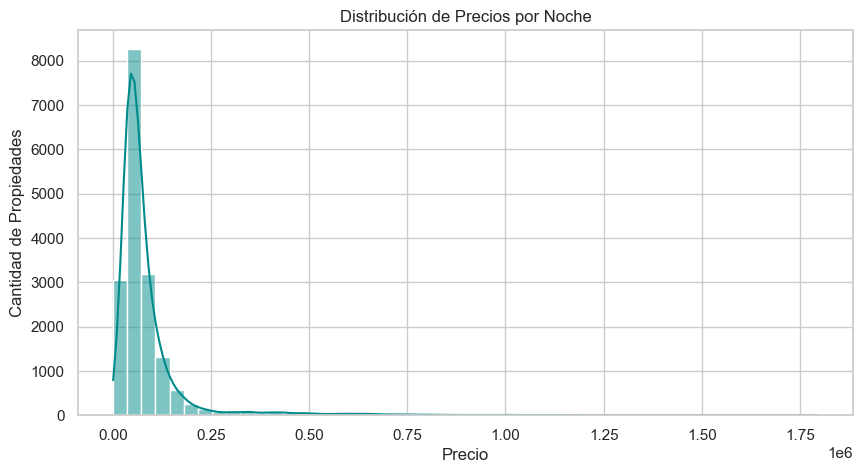

In [19]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='price', kde=True, bins=50, color='darkcyan')

plt.title('Distribución de Precios por Noche')
plt.xlabel('Precio')
plt.ylabel('Cantidad de Propiedades')
plt.show()

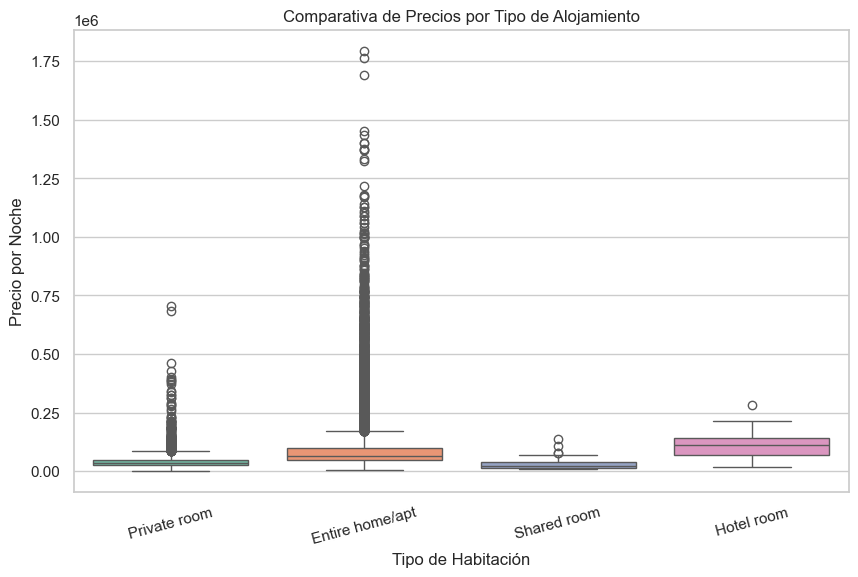

In [20]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='room_type', y='price', palette='Set2', hue='room_type', legend=False)

plt.title('Comparativa de Precios por Tipo de Alojamiento')
plt.xlabel('Tipo de Habitación')
plt.ylabel('Precio por Noche')
plt.xticks(rotation=15)
plt.show()

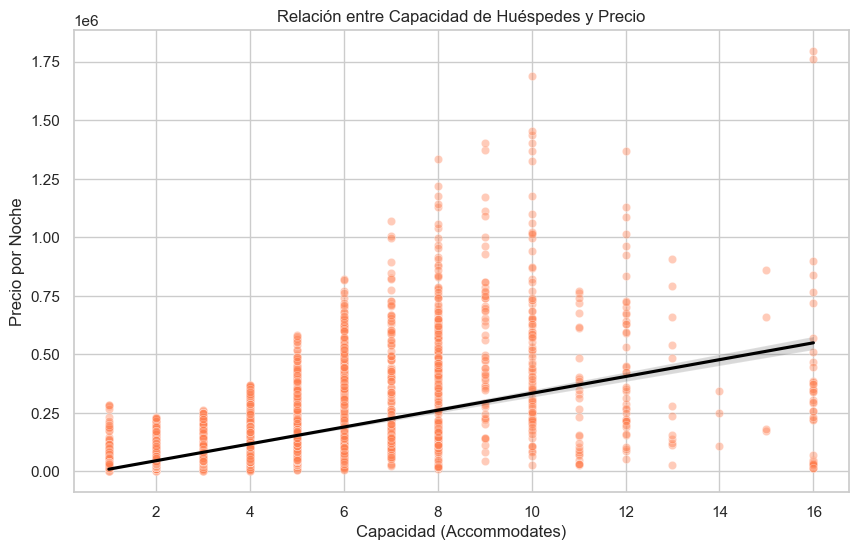

In [21]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='accommodates', y='price', alpha=0.4, color='coral')

sns.regplot(data=df, x='accommodates', y='price', scatter=False, color='black')

plt.title('Relación entre Capacidad de Huéspedes y Precio')
plt.xlabel('Capacidad (Accommodates)')
plt.ylabel('Precio por Noche')
plt.show()

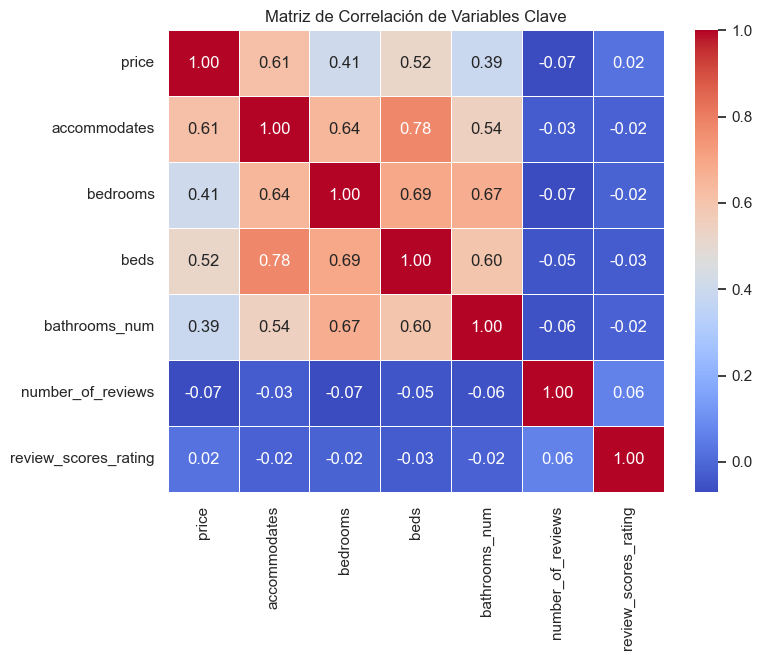

In [22]:
plt.figure(figsize=(8, 6))

columnas_numericas = ['price', 'accommodates', 'bedrooms', 'beds', 'bathrooms_num', 'number_of_reviews', 'review_scores_rating']
matriz_correlacion = df[columnas_numericas].corr()

sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Matriz de Correlación de Variables Clave')
plt.show()

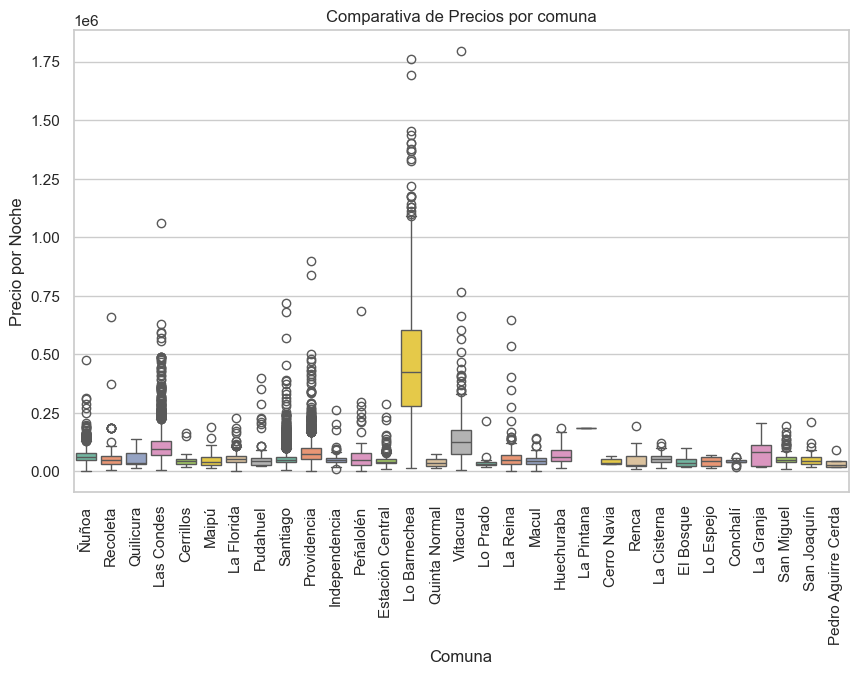

In [23]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='neighbourhood_cleansed', y='price', palette='Set2', legend=False)

plt.title('Comparativa de Precios por comuna')
plt.xlabel('Comuna')
plt.ylabel('Precio por Noche')
plt.xticks(rotation=90)
plt.show()

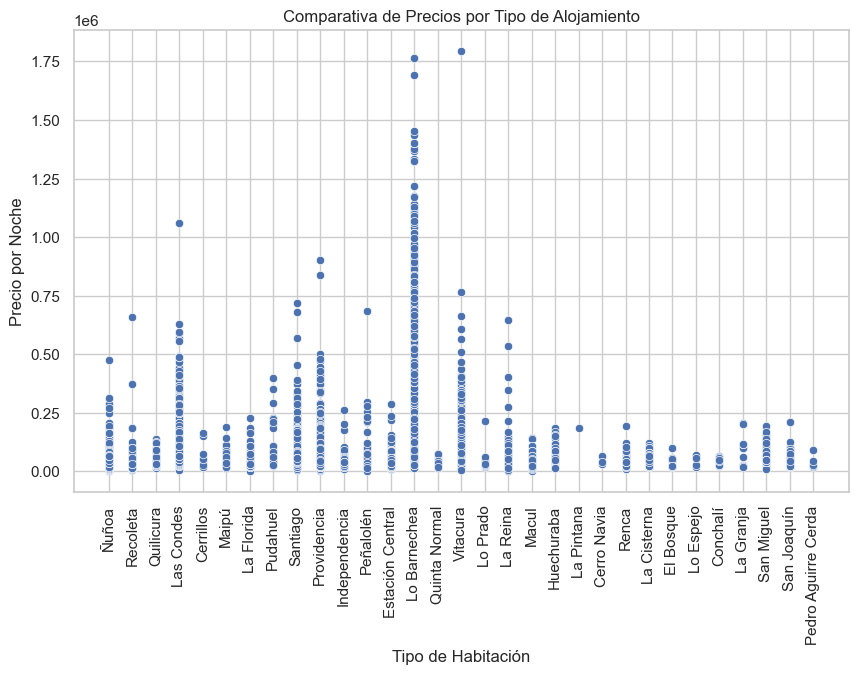

In [24]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='neighbourhood_cleansed', y='price', palette='Set2', legend=False)

plt.title('Comparativa de Precios por Tipo de Alojamiento')
plt.xlabel('Tipo de Habitación')
plt.ylabel('Precio por Noche')
plt.xticks(rotation=90)
plt.show()

Ingeneria de Caracteristicas

In [25]:
datos_metro = {
    'estacion': [
        'Los Dominicos', 'Escuela Militar', 'Tobalaba', 'Baquedano', 'La Moneda', 'Estación Central', 'Ecuador', 'San Pablo',
        'Vespucio Norte', 'Cal y Canto', 'Los Héroes', 'Franklin', 'La Cisterna', 'Hospital El Pino',
        'Plaza Quilicura', 'Universidad de Chile', 'Irarrázaval', 'Plaza Egaña', 'Fernando Castillo Velasco',
        'Francisco Bilbao', 'Macul', 'Plaza de Puente Alto',
        'Plaza de Maipú', 'Laguna Sur', 'Quinta Normal', 'Santa Ana', 'Vicente Valdés',
        'Cerrillos', 'Lo Valledor', 'Ñuble', 'Inés de Suárez', 'Los Leones'
    ],
    'linea': [
        'L1', 'L1', 'L1', 'L1', 'L1', 'L1', 'L1', 'L1',
        'L2', 'L2', 'L2', 'L2', 'L2', 'L2',
        'L3', 'L3', 'L3', 'L3', 'L3',
        'L4', 'L4', 'L4',
        'L5', 'L5', 'L5', 'L5', 'L5',
        'L6', 'L6', 'L6', 'L6', 'L6'
    ],
    'lat_metro': [
        -33.40800, -33.41429, -33.41724, -33.43695, -33.44485, -33.45087, -33.45626, -33.45147,
        -33.36906, -33.43265, -33.44521, -33.47598, -33.53724, -33.57861,
        -33.36214, -33.44292, -33.45422, -33.45263, -33.45305,
        -33.43232, -33.50428, -33.61205,
        -33.51001, -33.46788, -33.44215, -33.44026, -33.52445,
        -33.48316, -33.47587, -33.46797, -33.43981, -33.42234
    ],
    'lon_metro': [
        -70.55560, -70.58463, -70.60105, -70.62886, -70.65480, -70.67915, -70.70109, -70.73038,
        -70.66270, -70.65191, -70.66014, -70.64812, -70.66367, -70.63842,
        -70.73428, -70.65039, -70.62772, -70.57018, -70.55014,
        -70.58554, -70.60831, -70.57564,
        -70.75731, -70.74902, -70.68112, -70.66046, -70.59775,
        -70.70311, -70.68266, -70.62534, -70.61271, -70.60813
    ]
}

df_metro = pd.DataFrame(datos_metro)

In [26]:
def calcular_metro_mas_cercano(df, df_metro):
    coords_propiedades = df[['latitude', 'longitude']].values
    coords_metro = df_metro[['lat_metro', 'lon_metro']].values
    matriz_distancias_km = cdist(coords_propiedades, coords_metro, metric='euclidean') * 111.1
    indices_metro_cercano = np.argmin(matriz_distancias_km, axis=1)
    distancias_minimas_km = np.min(matriz_distancias_km, axis=1)
    df['estacion_metro_cercana'] = df_metro['estacion'].values[indices_metro_cercano]
    df['distancia_metro_km'] = distancias_minimas_km
    df['minutos_al_metro'] = df['distancia_metro_km'] * 12
    return df

df = calcular_metro_mas_cercano(df, df_metro)

print(df[['neighbourhood_cleansed', 'estacion_metro_cercana', 'minutos_al_metro']].head(10))

  neighbourhood_cleansed estacion_metro_cercana  minutos_al_metro
0                  Ñuñoa       Francisco Bilbao              7.71
1               Recoleta            Cal y Canto             19.78
2               Recoleta            Cal y Canto             15.06
3               Recoleta            Cal y Canto             20.84
4               Recoleta            Cal y Canto             17.22
5               Recoleta            Cal y Canto             14.56
6              Quilicura        Plaza Quilicura             33.61
7             Las Condes        Escuela Militar              7.08
8              Cerrillos              Cerrillos             25.93
9                  Maipú             Laguna Sur             24.05


In [27]:
df.head()

,id,latitude,longitude,neighbourhood_cleansed,room_type,property_type,accommodates,bedrooms,beds,bathrooms_text,amenities,price,estimated_occupancy_l365d,estimated_revenue_l365d,host_is_superhost,calculated_host_listings_count,minimum_nights,number_of_reviews,review_scores_rating,review_scores_cleanliness,review_scores_location,bathrooms_num,is_shared_bathroom,estacion_metro_cercana,distancia_metro_km,minutos_al_metro
0,978070332077815549,-33.44,-70.58,Ñuñoa,Private room,Private room in home,2,NaN,1.00,1 shared bath,"[""Free parking on premises"", ""Wifi"", ""Kitchen""...",45647.00,0,0.00,f,5,4.00,2,5.00,5.00,5.00,1.00,1,Francisco Bilbao,0.64,7.71
1,1069858035768058539,-33.42,-70.64,Recoleta,Private room,Private room in condo,1,1.00,1.00,0 shared baths,"[""Wifi"", ""Smoke alarm"", ""Fire extinguisher"", ""...",19856.00,48,953088.00,f,1,1.00,8,5.00,5.00,4.88,0.00,1,Cal y Canto,1.65,19.78
2,37181369,-33.42,-70.65,Recoleta,Entire home/apt,Entire rental unit,3,1.00,2.00,1 bath,"[""Microwave"", ""Wine glasses"", ""Kitchen"", ""Pets...",46776.00,144,6735744.00,t,1,1.00,126,4.74,4.85,4.81,1.00,0,Cal y Canto,1.25,15.06
3,1257358306712011993,-33.42,-70.64,Recoleta,Private room,Private room in rental unit,1,NaN,1.00,1 private bath,"[""Smoking allowed"", ""Kitchen"", ""Fire extinguis...",25572.00,0,0.00,f,1,1.00,0,NaN,NaN,NaN,1.00,0,Cal y Canto,1.74,20.84
4,868747298775934782,-33.42,-70.64,Recoleta,Entire home/apt,Entire rental unit,3,2.00,2.00,1 bath,"[""Free parking on premises"", ""Kitchen"", ""Wifi""...",107043.50,0,0.00,f,1,2.00,0,NaN,NaN,NaN,1.00,0,Cal y Canto,1.43,17.22


In [28]:
def limpiar_lista_amenities(texto):
    try:
        return ast.literal_eval(texto)
    except:
        return [x.strip('"\'[]{}') for x in texto.split(',')]

todas_las_amenities = []
for lista_str in df['amenities'].dropna():
    lista_limpia = limpiar_lista_amenities(lista_str)
    todas_las_amenities.extend([item.lower().strip() for item in lista_limpia])

amenities_unicas = sorted(list(set(todas_las_amenities)))



In [29]:
amenities_unicas

['- body soap',
 '. body soap',
 '. refrigerator',
 '. shampoo',
 '. sound system with aux',
 '1 inch hdtv with netflix',
 '1 inch tv',
 '1 samsung  refrigerator',
 '100 inch hdtv',
 '100 inch hdtv with apple tv',
 '100 inch hdtv with chromecast, netflix, premium cable, standard cable',
 '100 inch hdtv with premium cable',
 '100 inch hdtv with premium cable, apple tv, netflix, disney+',
 '101 inch hdtv',
 '102 inch hdtv',
 '106 inch hdtv with amazon prime video, disney+, hbo max, netflix, premium cable, standard cable',
 '106 inch tv with disney+, netflix, roku',
 '106 inch tv with roku, netflix',
 '109 inch hdtv',
 '109 inch hdtv with netflix',
 '120 inch hdtv',
 '120 inch hdtv with amazon prime video, netflix',
 '120 inch hdtv with netflix, premium cable',
 '125 inch hdtv',
 '127 inch hdtv with chromecast',
 '127 inch hdtv with chromecast, netflix',
 '127 inch hdtv with premium cable, standard cable',
 '127 inch hdtv with standard cable',
 '127 inch hdtv with standard cable, netflix'

In [30]:
# Asegurar que esté en minúsculas para la búsqueda
df['amenities_search'] = df['amenities'].astype(str).str.lower()

# Creación masiva de columnas binarias (1 o 0)
df['has_pool'] = df['amenities_search'].str.contains('pool|piscina').astype(int)
df['has_ac'] = df['amenities_search'].str.contains('air conditioning|aire acondicionado').astype(int)
df['has_parking'] = df['amenities_search'].str.contains('parking|estacionamiento|garage').astype(int)
df['has_gym'] = df['amenities_search'].str.contains('gym|gimnasio|fitness').astype(int)
df['has_wifi'] = df['amenities_search'].str.contains('wifi').astype(int)
df['has_workspace'] = df['amenities_search'].str.contains('dedicated workspace|zona de trabajo|escritorio').astype(int)
df['has_heating'] = df['amenities_search'].str.contains('heating|calefacción|estufa').astype(int)
df['allows_pets'] = df['amenities_search'].str.contains('pets allowed|mascotas').astype(int)
df['has_elevator'] = df['amenities_search'].str.contains('elevator|ascensor').astype(int)

# Limpiamos las columnas auxiliares/viejas de texto para dejar el DataFrame impecable
df = df.drop(columns=['amenities', 'amenities_search'])

In [31]:
df

,id,latitude,longitude,neighbourhood_cleansed,room_type,property_type,accommodates,bedrooms,beds,bathrooms_text,price,estimated_occupancy_l365d,estimated_revenue_l365d,host_is_superhost,calculated_host_listings_count,minimum_nights,number_of_reviews,review_scores_rating,review_scores_cleanliness,review_scores_location,bathrooms_num,is_shared_bathroom,estacion_metro_cercana,distancia_metro_km,minutos_al_metro,has_pool,has_ac,has_parking,has_gym,has_wifi,has_workspace,has_heating,allows_pets,has_elevator
0,978070332077815549,-33.44,-70.58,Ñuñoa,Private room,Private room in home,2,NaN,1.00,1 shared bath,45647.00,0,0.00,f,5,4.00,2,5.00,5.00,5.00,1.00,1,Francisco Bilbao,0.64,7.71,0,0,1,0,1,1,0,0,0
1,1069858035768058539,-33.42,-70.64,Recoleta,Private room,Private room in condo,1,1.00,1.00,0 shared baths,19856.00,48,953088.00,f,1,1.00,8,5.00,5.00,4.88,0.00,1,Cal y Canto,1.65,19.78,0,0,0,0,1,0,0,0,0
2,37181369,-33.42,-70.65,Recoleta,Entire home/apt,Entire rental unit,3,1.00,2.00,1 bath,46776.00,144,6735744.00,t,1,1.00,126,4.74,4.85,4.81,1.00,0,Cal y Canto,1.25,15.06,1,0,1,0,1,0,0,1,1
3,1257358306712011993,-33.42,-70.64,Recoleta,Private room,Private room in rental unit,1,NaN,1.00,1 private bath,25572.00,0,0.00,f,1,1.00,0,NaN,NaN,NaN,1.00,0,Cal y Canto,1.74,20.84,0,1,0,0,0,1,0,0,0
4,868747298775934782,-33.42,-70.64,Recoleta,Entire home/apt,Entire rental unit,3,2.00,2.00,1 bath,107043.50,0,0.00,f,1,2.00,0,NaN,NaN,NaN,1.00,0,Cal y Canto,1.43,17.22,0,0,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18529,1438001883419884214,-33.42,-70.59,Las Condes,Entire home/apt,Entire rental unit,4,2.00,2.00,2 baths,167533.00,228,38197524.00,f,152,1.00,38,4.71,4.95,4.97,2.00,0,Escuela Militar,0.20,2.41,1,0,1,1,1,1,1,0,1
18530,1706896686873108784,-33.44,-70.66,Santiago,Entire home/apt,Entire rental unit,6,2.00,4.00,2 baths,43492.50,0,0.00,f,1,2.00,0,NaN,NaN,NaN,2.00,0,Cal y Canto,0.61,7.35,1,0,1,1,1,0,0,1,1
18531,1348051252334482576,-33.42,-70.59,Las Condes,Entire home/apt,Entire rental unit,6,2.00,4.00,1.5 baths,137380.00,168,23079840.00,t,69,2.00,39,4.79,4.69,4.95,1.50,0,Tobalaba,0.80,9.56,0,1,1,0,1,0,1,1,0
18532,1434986836810175516,-33.44,-70.67,Santiago,Entire home/apt,Entire rental unit,2,1.00,1.00,1 bath,55192.50,120,6623100.00,f,32,1.00,20,4.70,4.85,4.70,1.00,0,Santa Ana,1.04,12.47,1,0,1,1,1,1,1,0,1


---
## 4. Modelado / Análisis Avanzado
*Separación de datos, entrenamiento de algoritmos y evaluación.*

In [32]:
columnas_modelo = [
    'accommodates', 'bedrooms', 'beds', 'bathrooms_num', 'is_shared_bathroom',
    'minutos_al_metro', 
    'has_pool', 'has_ac', 'has_parking', 'has_gym', 'has_wifi', 'has_workspace', 'has_heating', 'allows_pets', 'has_elevator',
    'minimum_nights', 'host_is_superhost',
    'room_type', 'neighbourhood_cleansed',
    'price' 
]

df_ml = df[columnas_modelo].dropna()

if df_ml['host_is_superhost'].dtype == 'object':
    df_ml['host_is_superhost'] = df_ml['host_is_superhost'].map({'t': 1, 'f': 0}).fillna(0)

In [33]:
df_ml['host_is_superhost'] = df_ml['host_is_superhost'].replace({'t': 1, 'f': 0, 't': 1.0, 'f': 0.0})

df_ml['host_is_superhost'] = pd.to_numeric(df_ml['host_is_superhost'], errors='coerce').fillna(0)

df_procesado = pd.get_dummies(df_ml, columns=['room_type', 'neighbourhood_cleansed'], drop_first=True)

df_procesado = df_procesado.astype(float)



In [34]:
df_procesado

,accommodates,bedrooms,beds,bathrooms_num,is_shared_bathroom,minutos_al_metro,has_pool,has_ac,has_parking,has_gym,has_wifi,has_workspace,has_heating,allows_pets,has_elevator,minimum_nights,host_is_superhost,price,room_type_Hotel room,room_type_Private room,room_type_Shared room,neighbourhood_cleansed_Cerro Navia,neighbourhood_cleansed_Conchalí,neighbourhood_cleansed_El Bosque,neighbourhood_cleansed_Estación Central,neighbourhood_cleansed_Huechuraba,neighbourhood_cleansed_Independencia,neighbourhood_cleansed_La Cisterna,neighbourhood_cleansed_La Florida,neighbourhood_cleansed_La Granja,neighbourhood_cleansed_La Pintana,neighbourhood_cleansed_La Reina,neighbourhood_cleansed_Las Condes,neighbourhood_cleansed_Lo Barnechea,neighbourhood_cleansed_Lo Espejo,neighbourhood_cleansed_Lo Prado,neighbourhood_cleansed_Macul,neighbourhood_cleansed_Maipú,neighbourhood_cleansed_Pedro Aguirre Cerda,neighbourhood_cleansed_Peñalolén,neighbourhood_cleansed_Providencia,neighbourhood_cleansed_Pudahuel,neighbourhood_cleansed_Quilicura,neighbourhood_cleansed_Quinta Normal,neighbourhood_cleansed_Recoleta,neighbourhood_cleansed_Renca,neighbourhood_cleansed_San Joaquín,neighbourhood_cleansed_San Miguel,neighbourhood_cleansed_Santiago,neighbourhood_cleansed_Vitacura,neighbourhood_cleansed_Ñuñoa
1,1.00,1.00,1.00,0.00,1.00,19.78,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,19856.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
2,3.00,1.00,2.00,1.00,0.00,15.06,1.00,0.00,1.00,0.00,1.00,0.00,0.00,1.00,1.00,1.00,1.00,46776.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
4,3.00,2.00,2.00,1.00,0.00,17.22,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,2.00,0.00,107043.50,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
5,5.00,3.00,3.00,2.00,0.00,14.56,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.00,0.00,56615.33,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
7,2.00,1.00,1.00,1.00,1.00,7.08,0.00,0.00,1.00,0.00,1.00,0.00,0.00,1.00,0.00,1.00,1.00,32627.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18529,4.00,2.00,2.00,2.00,0.00,2.41,1.00,0.00,1.00,1.00,1.00,1.00,1.00,0.00,1.00,1.00,0.00,167533.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
18530,6.00,2.00,4.00,2.00,0.00,7.35,1.00,0.00,1.00,1.00,1.00,0.00,0.00,1.00,1.00,2.00,0.00,43492.50,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00
18531,6.00,2.00,4.00,1.50,0.00,9.56,0.00,1.00,1.00,0.00,1.00,0.00,1.00,1.00,0.00,2.00,1.00,137380.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
18532,2.00,1.00,1.00,1.00,0.00,12.47,1.00,0.00,1.00,1.00,1.00,1.00,1.00,0.00,1.00,1.00,0.00,55192.50,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00


In [35]:
X = df_procesado.drop(columns=['price'])
y = df_procesado['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Muestras de entrenamiento (X_train): {X_train.shape[0]}")
print(f"Muestras de prueba (X_test): {X_test.shape[0]}\n")

Muestras de entrenamiento (X_train): 11949
Muestras de prueba (X_test): 2988



In [36]:


param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 5, 10, 15, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=30,          
    cv=5,                
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train, y_train)

print("--- MEJORES HIPERPARÁMETROS ENCONTRADOS ---")
print(random_search.best_params_)
print(f"Mejor R² promedio en validación cruzada: {random_search.best_score_:.4f}")

modelo_airbnb = random_search.best_estimator_


Fitting 5 folds for each of 30 candidates, totalling 150 fits
--- MEJORES HIPERPARÁMETROS ENCONTRADOS ---
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': None}
Mejor R² promedio en validación cruzada: 0.8295


In [37]:
predicciones = modelo_airbnb.predict(X_test)

mae = mean_absolute_error(y_test, predicciones)
r2 = r2_score(y_test, predicciones)

print("--- RESULTADOS DE LA EVALUACIÓN ---")
print(f"Error Absoluto Medio (MAE): ${mae:,.2f} CLP")
print(f"Coeficiente de Determinación (R²): {r2:.2f}")

--- RESULTADOS DE LA EVALUACIÓN ---
Error Absoluto Medio (MAE): $21,447.58 CLP
Coeficiente de Determinación (R²): 0.80


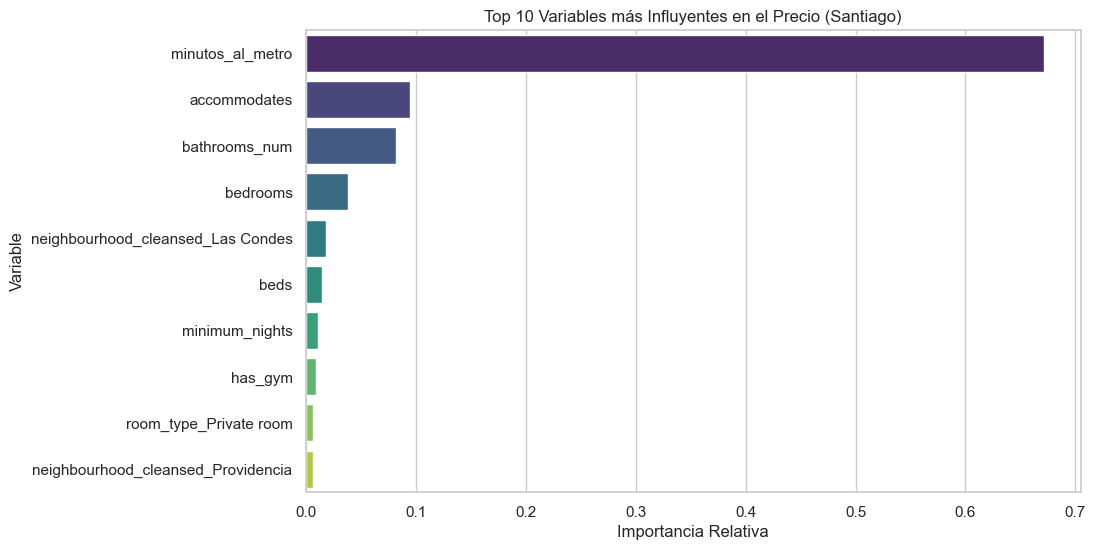

In [38]:
importancias = modelo_airbnb.feature_importances_
columnas_x = X.columns

df_importancia = pd.DataFrame({'Variable': columnas_x, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_importancia, x='Importancia', y='Variable', hue='Variable', palette='viridis', legend=False)
plt.title('Top 10 Variables más Influyentes en el Precio (Santiago)')
plt.xlabel('Importancia Relativa')
plt.ylabel('Variable')
plt.show()

In [39]:
scores_r2 = cross_val_score(modelo_airbnb, X, y, cv=5, scoring='r2', n_jobs=-1)

print("\n--- RESULTADOS DE CROSS-VALIDATION (R²) ---")
print(f"Puntajes por cada Fold: {scores_r2}")
print(f"R² Promedio: {scores_r2.mean():.2f} (+/- {scores_r2.std() * 2:.3f})")


--- RESULTADOS DE CROSS-VALIDATION (R²) ---
Puntajes por cada Fold: [0.82968018 0.8255047  0.84641408 0.77854009 0.8357129 ]
R² Promedio: 0.82 (+/- 0.047)


**2° Modelo para construir la ocupacion 365 dias**

In [40]:

stats_barrio = df.groupby('neighbourhood_cleansed').agg(
    score_ocupacion_barrio=('estimated_occupancy_l365d', 'mean'),
    score_ingreso_anual_barrio=('estimated_revenue_l365d', 'median'),
    score_precio_noche_barrio=('price', 'median')
).reset_index()

In [41]:
df_final = df.merge(stats_barrio, on='neighbourhood_cleansed', how='left')

In [42]:
df_ml_1_limpio = df[columnas_modelo].copy().dropna()
df_ml_1_limpio['host_is_superhost'] = df_ml_1_limpio['host_is_superhost'].replace({'t': 1, 'f': 0, 't': 1.0, 'f': 0.0})
df_ml_1_limpio['host_is_superhost'] = pd.to_numeric(df_ml_1_limpio['host_is_superhost'], errors='coerce').fillna(0)

In [43]:
df_procesado_1 = pd.get_dummies(df_ml_1_limpio, columns=['room_type', 'neighbourhood_cleansed'], drop_first=True).astype(float)
X_1 = df_procesado_1.drop(columns=['price'], errors='ignore')
X_1 = X_1.reindex(columns=X_train.columns, fill_value=0)


In [44]:
df_final['prediccion_precio_ml'] = pd.Series(modelo_airbnb.predict(X_1), index=X_1.index)
df_final['prediccion_precio_ml'] = df_final['prediccion_precio_ml'].fillna(df_final['price'])

In [45]:
columnas_decimales = ['score_ocupacion_barrio', 'score_ingreso_anual_barrio', 'score_precio_noche_barrio', 'prediccion_precio_ml', 'price']

for col in columnas_decimales:
    df_final[col] = df_final[col].round(4).astype(str).str.replace('.', ',', regex=False)

In [46]:
df_final.head()

,id,latitude,longitude,neighbourhood_cleansed,room_type,property_type,accommodates,bedrooms,beds,bathrooms_text,price,estimated_occupancy_l365d,estimated_revenue_l365d,host_is_superhost,calculated_host_listings_count,minimum_nights,number_of_reviews,review_scores_rating,review_scores_cleanliness,review_scores_location,bathrooms_num,is_shared_bathroom,estacion_metro_cercana,distancia_metro_km,minutos_al_metro,has_pool,has_ac,has_parking,has_gym,has_wifi,has_workspace,has_heating,allows_pets,has_elevator,score_ocupacion_barrio,score_ingreso_anual_barrio,score_precio_noche_barrio,prediccion_precio_ml
0,978070332077815549,-33.44,-70.58,Ñuñoa,Private room,Private room in home,2,NaN,1.00,1 shared bath,"45647,0",0,0.00,f,5,4.00,2,5.00,5.00,5.00,1.00,1,Francisco Bilbao,0.64,7.71,0,0,1,0,1,1,0,0,0,"78,7632","2767821,0","60762,25","45647,0"
1,1069858035768058539,-33.42,-70.64,Recoleta,Private room,Private room in condo,1,1.00,1.00,0 shared baths,"19856,0",48,953088.00,f,1,1.00,8,5.00,5.00,4.88,0.00,1,Cal y Canto,1.65,19.78,0,0,0,0,1,0,0,0,0,"56,2539","771671,0","47057,5","26732,7295"
2,37181369,-33.42,-70.65,Recoleta,Entire home/apt,Entire rental unit,3,1.00,2.00,1 bath,"46776,0",144,6735744.00,t,1,1.00,126,4.74,4.85,4.81,1.00,0,Cal y Canto,1.25,15.06,1,0,1,0,1,0,0,1,1,"56,2539","771671,0","47057,5","48706,7701"
3,1257358306712011993,-33.42,-70.64,Recoleta,Private room,Private room in rental unit,1,NaN,1.00,1 private bath,"25572,0",0,0.00,f,1,1.00,0,NaN,NaN,NaN,1.00,0,Cal y Canto,1.74,20.84,0,1,0,0,0,1,0,0,0,"56,2539","771671,0","47057,5","25572,0"
4,868747298775934782,-33.42,-70.64,Recoleta,Entire home/apt,Entire rental unit,3,2.00,2.00,1 bath,"107043,5",0,0.00,f,1,2.00,0,NaN,NaN,NaN,1.00,0,Cal y Canto,1.43,17.22,0,0,1,0,1,0,0,0,0,"56,2539","771671,0","47057,5","84373,7292"


In [47]:
df_final.to_csv(DATA_PROCESSED / "airbnb_santiago_final_powerbi.csv", index=False, sep=';', encoding='utf-8-sig')


---
## 5. Conclusiones e Insights
*Resultados clave y próximos pasos.*

- **Insight 1:** El review o las reseñas no influyen en el precio del inmueble
- **Insight 2:** La variable más importante es la cercania en minutos con el metro mas cercano, a la hora de la prediccion del precio por noche del inmueble.
- **Próximos pasos:** Desplegar un modelo que dado un valor de un inmueble prediga el ROI dado su precio esperado y las noches en arriendo esperadas

In [48]:
joblib.dump(modelo_airbnb, MODELS_DIR / "modelo_airbnb.pkl")
joblib.dump(X_train.columns.tolist(), MODELS_DIR / "columnas_entrenamiento.pkl")
df_final.to_csv(DATA_PROCESSED / "airbnb_santiago_clean.csv", index=False, sep=';', encoding='utf-8-sig')



In [ ]:
codigo_streamlit = """import streamlit as st
import pandas as pd
import numpy as np
import joblib
import os
import urllib.request

# Configuración de la página
st.set_page_config(page_title="Simulador de precios Airbnb Santiago", layout="wide")

# Cargar el modelo y los datos desde la nube de forma asíncrona
@st.cache_resource
def cargar_componentes():
    archivo_modelo = 'modelo_airbnb.pkl'
    archivo_csv = 'airbnb_santiago_clean.csv'
    columnas_x = 'columnas_entrenamiento.pkl' # Este queda local desde GitHub
    
    # 1. Descarga automática del Modelo si no existe en el servidor de Streamlit
    if not os.path.exists(archivo_modelo):
        with st.spinner('Descargando modelo predictivo de IA desde Google Drive... (Esto solo toma unos segundos)'):
            id_modelo_drive = "1yCPNrclsoaT_1SjjjmnyLHduouK4Ehps" 
            url_modelo = f"https://docs.google.com/uc?export=download&id={id_modelo_drive}"
            urllib.request.urlretrieve(url_modelo, archivo_modelo)
            
    # 2. Descarga automática del CSV si no existe en el servidor de Streamlit
    if not os.path.exists(archivo_csv):
        with st.spinner('Descargando base de datos optimizada...'):
            # 🛑 REEMPLAZA ESTO por el ID de tu archivo CSV en Google Drive
            id_csv_drive = "TU_ID_DEL_CSV_AQUÍ" 
            url_csv = f"https://docs.google.com/uc?export=download&id={id_csv_drive}"
            urllib.request.urlretrieve(url_csv, archivo_csv)
            
    modelo = joblib.load(archivo_modelo)
    columnas_x_data = joblib.load(columnas_x)
    df = pd.read_csv(archivo_csv, sep=';')
    return modelo, columnas_x_data, df

modelo, columnas_x, df = cargar_componentes()

# --- INTERFAZ DE USUARIO ---
st.title("Simulador de Precios Airbnb Santiago (Machine Learning)")
st.caption("Esta aplicación predice en tiempo real el precio óptimo usando un modelo RandomForest.")

st.sidebar.header("Filtros de la Propiedad")

comunas_disponibles = sorted(df['neighbourhood_cleansed'].unique())
comuna_sel = st.sidebar.selectbox("Selecciona la Comuna", comunas_disponibles)

room_types = sorted(df['room_type'].unique())
room_sel = st.sidebar.selectbox("Tipo de Habitación", room_types)

minutos_metro_sel = st.sidebar.slider("Minutos Caminando al Metro", 0, 30, 5)
accommodates_sel = st.sidebar.slider("Capacidad de Huéspedes", int(df['accommodates'].min()), int(df['accommodates'].max()), 2)
bedrooms_sel = st.sidebar.slider("Dormitorios", int(df['bedrooms'].min()), int(df['bedrooms'].max()), 1)
bathrooms_sel = st.sidebar.slider("Baños", float(df['bathrooms_num'].min()), float(df['bathrooms_num'].max()), 1.0)
min_nights_sel = st.sidebar.slider("Noches Mínimas", int(df['minimum_nights'].min()), 30, 1)

# --- FILTRADO DINÁMICO CON COPIA LIMPIA ---
df_filtrado = df[
    (df['neighbourhood_cleansed'] == comuna_sel) &
    (df['room_type'] == room_sel) &
    (df['accommodates'] >= accommodates_sel) &
    (df['bedrooms'] == bedrooms_sel) &
    (df['bathrooms_num'] == bathrooms_sel) &
    (df['minimum_nights'] <= min_nights_sel) &
    (df['minutos_al_metro'].between(minutos_metro_sel - 3, minutos_metro_sel + 3))
].copy().reset_index(drop=True)

# --- PROCESAMIENTO DE MACHINE LEARNING EN VIVO ---
input_data = pd.DataFrame(0, index=[0], columns=columnas_x)

input_data['minutos_al_metro'] = minutos_metro_sel
input_data['accommodates'] = accommodates_sel
input_data['bedrooms'] = bedrooms_sel
input_data['bathrooms_num'] = bathrooms_sel
input_data['minimum_nights'] = min_nights_sel

col_room = f"room_type_{room_sel}"
col_neigh = f"neighbourhood_cleansed_{comuna_sel}"

if col_room in input_data.columns:
    input_data[col_room] = 1.0
if col_neigh in input_data.columns:
    input_data[col_neigh] = 1.0

precio_predicho = modelo.predict(input_data)[0]
mae = 21815

# --- DISEÑO DEL DASHBOARD (MÉTRICAS) ---
col1, col2, col3 = st.columns(3)
with col1:
    st.metric(label="Precio Mínimo Sugerido", value=f"${int(precio_predicho - mae):,}".replace(",", "."))
with col2:
    st.metric(label="PRECIO SUGERIDO", value=f"${int(precio_predicho):,}".replace(",", "."), delta="Recomendado")
with col3:
    st.metric(label="Precio Máximo Sugerido", value=f"${int(precio_predicho + mae):,}".replace(",", "."))

st.markdown("---")

# --- MAPA URBANO REACTIVO ---
st.subheader(f"Propiedades encontradas con tus características ({len(df_filtrado)} disponibles)")

if not df_filtrado.empty:
    df_mapa = df_filtrado[['latitude', 'longitude', 'price']].rename(columns={'latitude': 'lat', 'longitude': 'lon'}).dropna()
    map_key = f"mapa_{comuna_sel}_{room_sel}_{minutos_metro_sel}_{accommodates_sel}_{bedrooms_sel}"
    st.map(df_mapa, size='price', key=map_key)
else:
    st.warning("No se encontraron propiedades exactas con esta combinación de filtros en la base de datos. Intenta flexibilizar los criterios.")
"""

with open("app.py", "w", encoding="utf-8") as f:
    f.write(codigo_streamlit)

requirements_contenido = """streamlit
pandas
numpy
joblib
scikit-learn
"""

with open(RAIZ / "requirements.txt", "w", encoding="utf-8") as f:
    f.write(requirements_contenido)



In [50]:
joblib.dump(modelo_airbnb, 'modelo_airbnb.pkl.z', compress=3)

['modelo_airbnb.pkl.z']